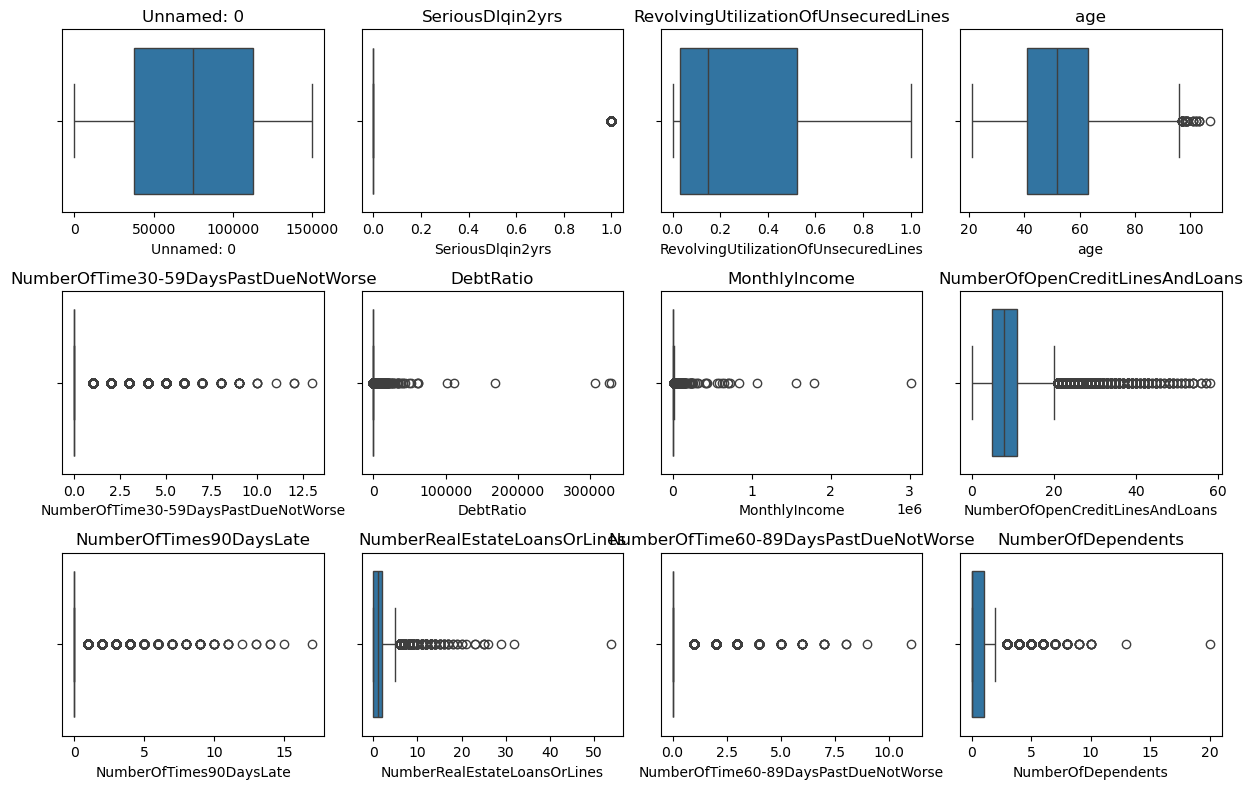

Train data shape:  (61105, 11)
Test data shape:  (15277, 11)


In [2]:
# Data Cleaning Specifications
# 1. Data Loading: Load dataset with pandas library, check basic data structure and types
# 2. Check and handle outliers in data: Detect outliers with box plot, process outliers using IQR method
# 3. Check and remove duplicate values in data, record the number of deleted rows
# 4. Perform normalization on data
# 5. Save cleaned data

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

data = pd.read_csv('3_finance.csv')
plt.figure(figsize=(12, 8))
numeric_cols = data.select_dtypes(include=['float64', 'int64']).columns

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3,4,i)
    sns.boxplot(x=data[col])
    plt.title(col)

plt.tight_layout()
plt.show()

Q1 = data[numeric_cols].quantile(0.25)
Q3 = data[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

data_cleaned = data[~((data[numeric_cols] < (Q1 - 1.5 * IQR)) | (data[numeric_cols] > (Q3 + 1.5 * IQR))).any(axis=1)]
duplicates = data_cleaned.duplicated()
num_duplicates = duplicates.sum()
data_cleaned = data_cleaned[~duplicates]

scaler = MinMaxScaler()
data_cleaned[numeric_cols] = scaler.fit_transform(data_cleaned[numeric_cols])

target_variable = 'SeriousDlqin2yrs'


X = data_cleaned.drop(columns=[target_variable])
y = data_cleaned[target_variable]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Train data shape: ', X_train.shape)
print('Test data shape: ', X_test.shape)
data_cleaned.to_csv('3_finance_cleaned.csv', index=False)